In [20]:
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
import umap
import pandas as pd
from pathlib import Path

In [21]:
opt_results_dir = Path("opt_results") / "run_combined_sim"
oracle_name = "oracle"

In [22]:


# ============================================================================
# 1. LOAD OPTIMIZED MOLECULES FUNCTION
# ============================================================================

def load_optimized_molecules(method, seeds=None, topk=500):
    """
    Load top-k optimized molecules from optimization results across multiple seeds.
    
    Args:
        method: Optimization method name (e.g., 'graph_ga', 'gp_bo')
        seeds: List of seed numbers or None to use default [0, 1, 2, 3, 5]
        topk: Number of top-scoring molecules to return per seed (default: 100)
    
    Returns:
        DataFrame with columns: smiles, rnamigos2_score, iteration, seed
    """
    if seeds is None:
        seeds = [0, 1, 2, 3, 5]  # Default seeds
    
    all_dfs = []
    
    for seed in seeds:
        csv_path = opt_results_dir / method / f"results_{method}_{oracle_name}_{seed}.csv"
        
        if not csv_path.exists():
            print(f"Warning: File not found: {csv_path}")
            continue
        
        df = pd.read_csv(csv_path)
        # Sort by score descending and take top-k
        df_sorted = df.sort_values('rnamigos2_score', ascending=False)
        
        if topk is not None:
            df_sorted = df_sorted.head(topk)
        
        # Add seed column to track which seed each molecule came from
        df_sorted['seed'] = seed
        all_dfs.append(df_sorted)
        print(f"  Loaded {len(df_sorted)} molecules from seed {seed}")
    
    if len(all_dfs) == 0:
        raise ValueError(f"No valid data found for method {method}")
    
    # Combine all DataFrames
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Total loaded: {len(combined_df)} optimized molecules from {method} ({len(all_dfs)} seeds)")
    
    return combined_df

In [23]:
# ============================================================================
# 2. LOAD ROBIN DATASET
# ============================================================================

print("=" * 80)
print("Loading ROBIN Dataset")
print("=" * 80)

# Load ROBIN dataset - adjust path to go up one level
robin_path = Path("../robin_clean.csv")
robin_df = pd.read_csv(robin_path)

# Select only Smile and TPP columns
robin_df = robin_df[['Smile', 'TPP']].copy()
print(f"Loaded {len(robin_df)} molecules from ROBIN dataset")
print(f"  - Non-hits (TPP=0): {(robin_df['TPP'] == 0).sum()}")
print(f"  - Hits (TPP=1): {(robin_df['TPP'] == 1).sum()}")

Loading ROBIN Dataset
Loaded 24501 molecules from ROBIN dataset
  - Non-hits (TPP=0): 24339
  - Hits (TPP=1): 162


In [24]:

# ============================================================================
# 3. SMILES TO ECFP FINGERPRINTS
# ============================================================================

def smiles_to_ecfp(smiles_list, radius=2, n_bits=1024):
    """
    Convert SMILES strings to ECFP fingerprints.
    
    Args:
        smiles_list: List of SMILES strings
        radius: Morgan fingerprint radius (default: 2, equivalent to ECFP4)
        n_bits: Number of bits in fingerprint (default: 1024)
    
    Returns:
        numpy array of shape (n_molecules, n_bits)
    """
    fingerprints = []
    valid_indices = []
    
    for idx, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
            fp = mfpgen.GetFingerprint(mol)
            fingerprints.append(np.array(fp))
            valid_indices.append(idx)
        else:
            print(f"Warning: Invalid SMILES at index {idx}: {smiles}")
    
    if len(fingerprints) == 0:
        raise ValueError("No valid molecules found")
    
    return np.array(fingerprints), valid_indices




In [25]:
# Convert ROBIN SMILES to fingerprints
print("Processing ROBIN molecules...")
robin_fps, robin_valid_idx = smiles_to_ecfp(robin_df['Smile'].tolist())
robin_df_valid = robin_df.iloc[robin_valid_idx].reset_index(drop=True)
print(f"  Valid ROBIN molecules: {len(robin_fps)}/{len(robin_df)}")

Processing ROBIN molecules...


[10:43:33] Conflicting single bond directions around double bond at index 27.
[10:43:33]   BondStereo set to STEREONONE and single bond directions set to NONE.


  Valid ROBIN molecules: 24501/24501


In [39]:
# Load graph_ga optimized molecules from all 5 seed runs (top 100 per seed)
method = 'gp_bo'
opt_df = load_optimized_molecules(method, topk=500)


  Loaded 500 molecules from seed 0
Total loaded: 500 optimized molecules from gp_bo (1 seeds)


In [40]:
# Convert optimized SMILES to fingerprints
print("Processing optimized molecules...")
opt_fps, opt_valid_idx = smiles_to_ecfp(opt_df['smiles'].tolist())
opt_df_valid = opt_df.iloc[opt_valid_idx].reset_index(drop=True)
print(f"  Valid optimized molecules: {len(opt_fps)}/{len(opt_df)}")

Processing optimized molecules...
  Valid optimized molecules: 500/500


In [41]:
# ============================================================================
# 4. UMAP DIMENSIONALITY REDUCTION
# ============================================================================

print("\n" + "=" * 80)
print("Applying UMAP Dimensionality Reduction")
print("=" * 80)

# Combine all fingerprints
all_fps = np.vstack([robin_fps, opt_fps])
print(f"Total molecules for UMAP: {len(all_fps)}")

# Apply UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='jaccard', random_state=42)
embedding = reducer.fit_transform(all_fps)

# Split embeddings back into ROBIN and optimized
robin_embedding = embedding[:len(robin_fps)]
opt_embedding = embedding[len(robin_fps):]

print(f"UMAP embedding shape: {embedding.shape}")


Applying UMAP Dimensionality Reduction


Total molecules for UMAP: 25001


/home/wangx86/miniconda3/envs/rnamigo2/lib/python3.10/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/wangx86/miniconda3/envs/rnamigo2/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (25001, 2)



Creating Visualization


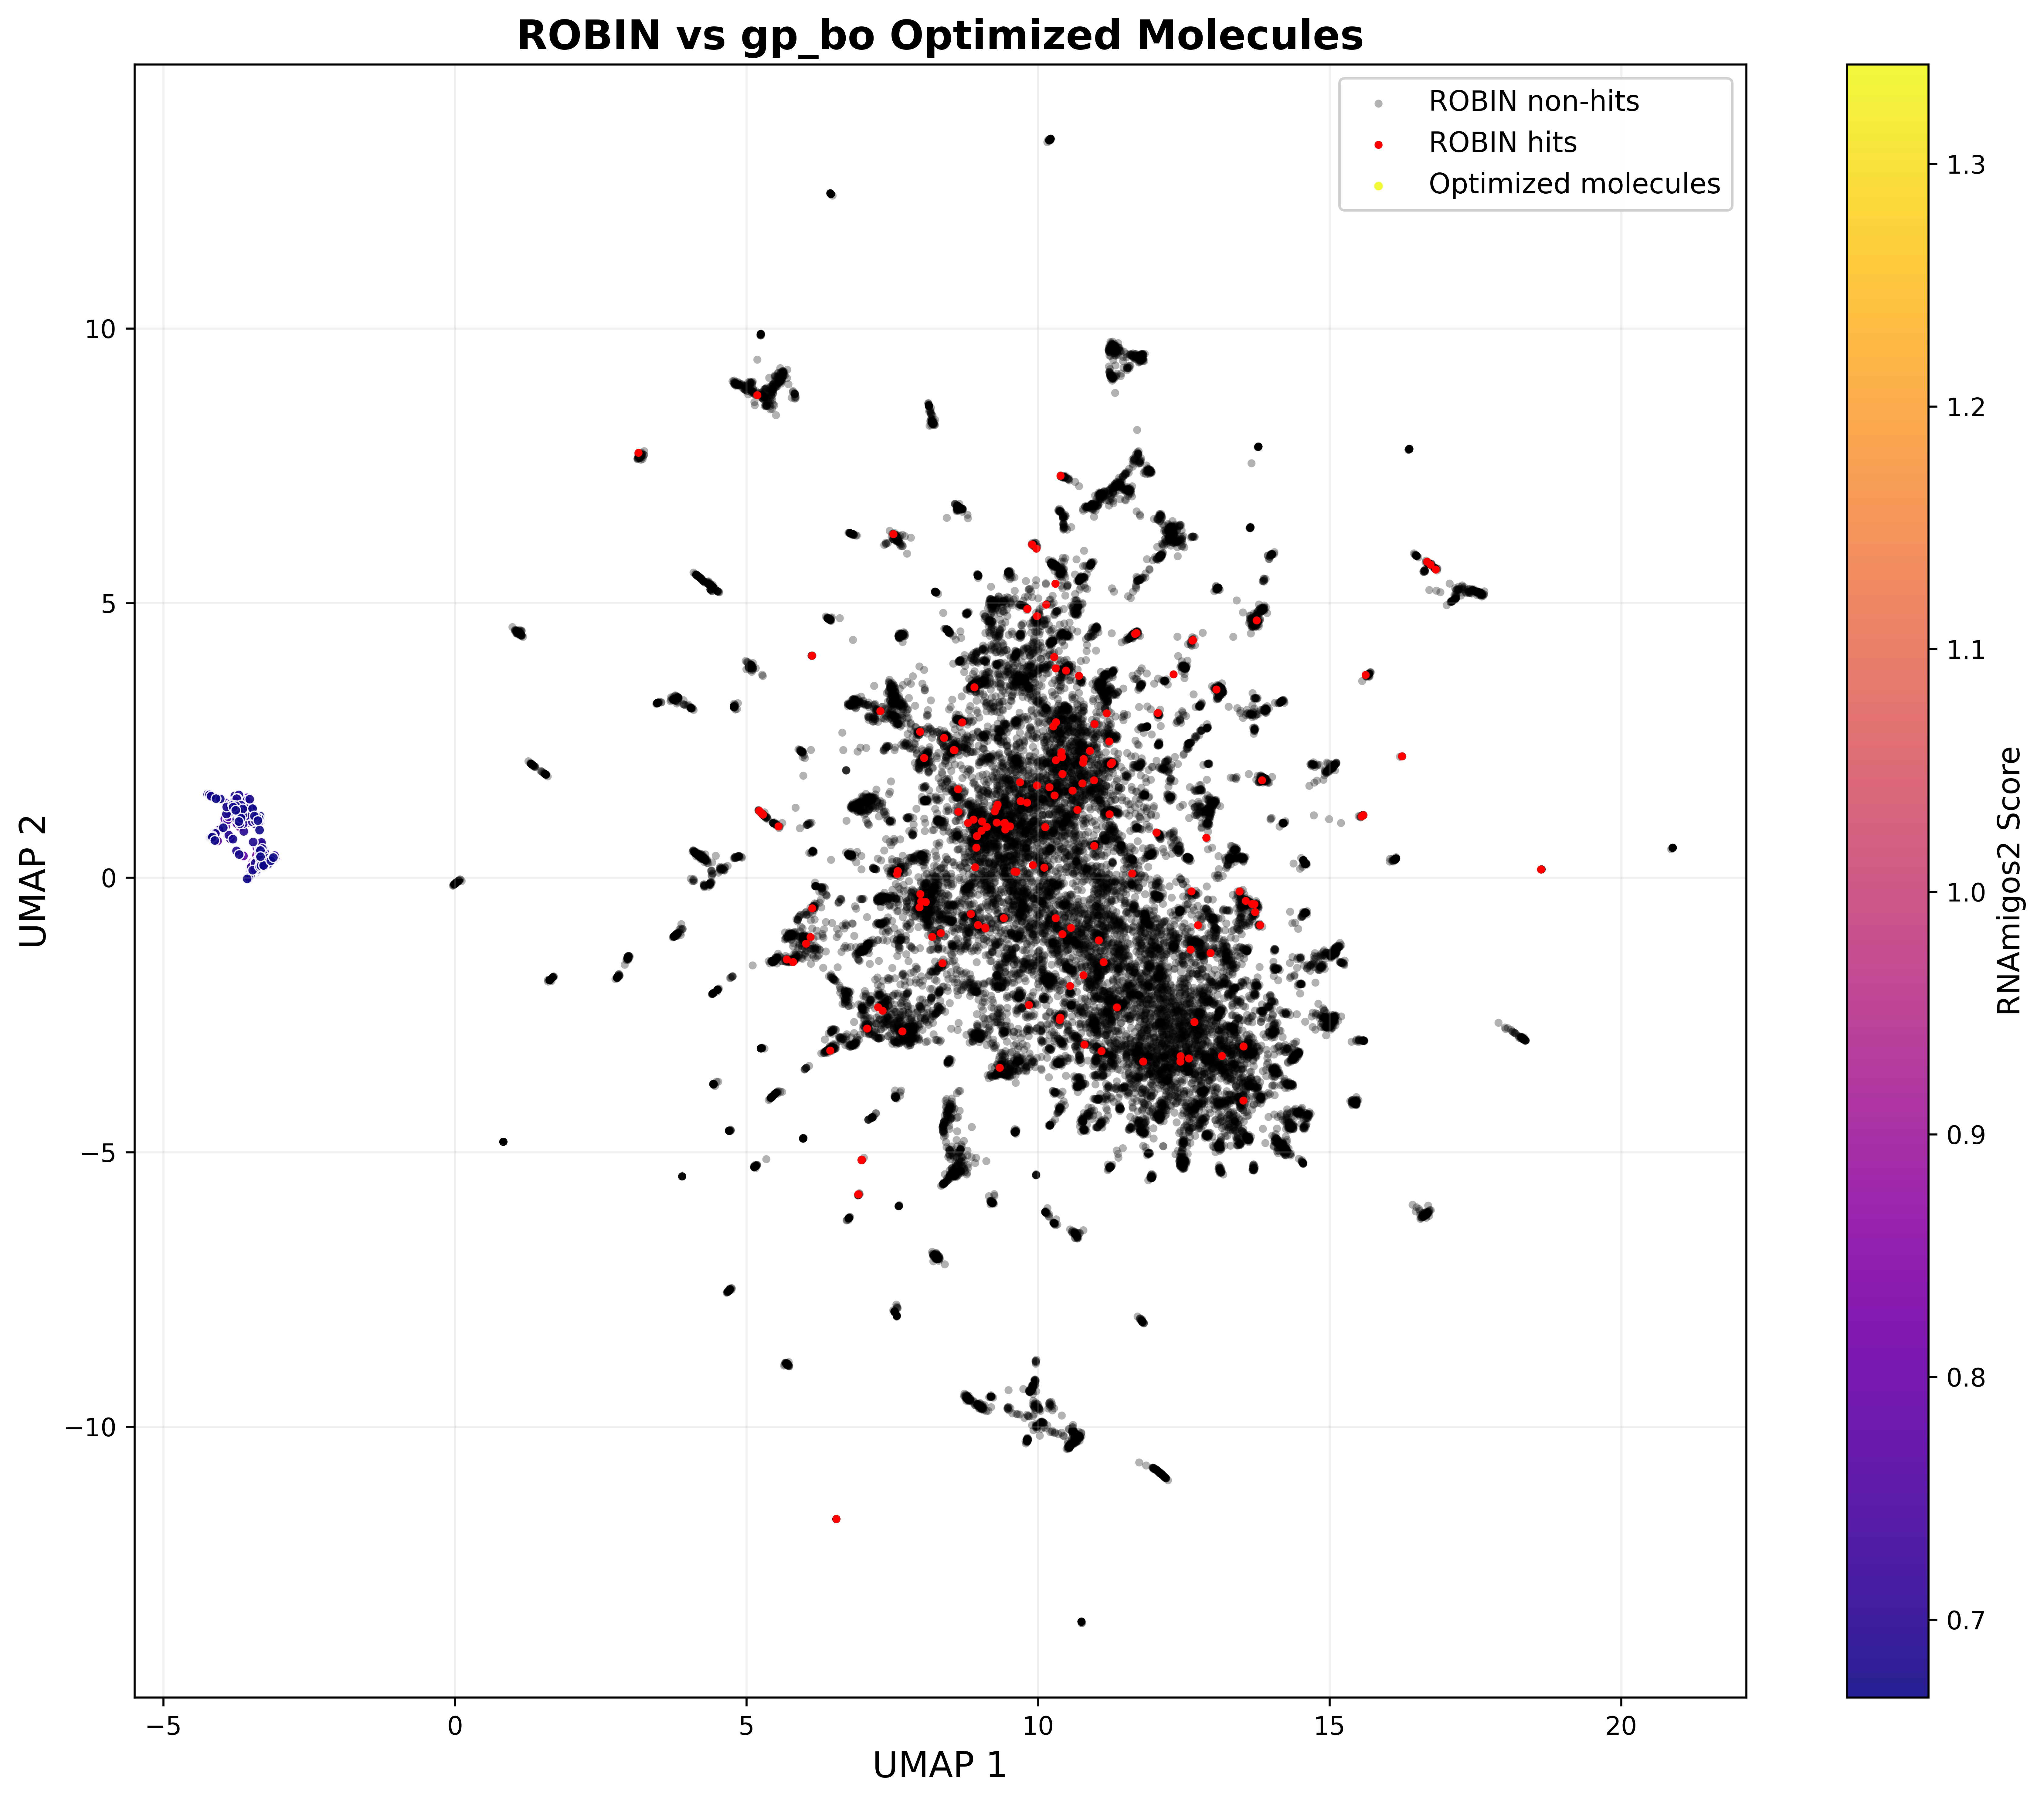


✅ Visualization complete!
   ROBIN molecules: 24501 (24339 non-hits, 162 hits)
   Optimized molecules: 500
   Score range: [0.668, 1.341]


In [42]:
# ============================================================================
# 5. VISUALIZATION
# ============================================================================

print("\n" + "=" * 80)
print("Creating Visualization")
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 10), dpi=600)

# Plot ROBIN molecules first (background layer)
# Black for non-hits (TPP=0), Red for hits (TPP=1)
robin_non_hits = robin_df_valid['TPP'] == 0
robin_hits = robin_df_valid['TPP'] == 1

ax.scatter(robin_embedding[robin_non_hits, 0], 
           robin_embedding[robin_non_hits, 1],
           c='black', s=10, alpha=0.3, label='ROBIN non-hits', edgecolors='none')

ax.scatter(robin_embedding[robin_hits, 0], 
           robin_embedding[robin_hits, 1],
           c='red', s=10, alpha=1, label='ROBIN hits', edgecolors='none')

# Plot optimized molecules on top (foreground layer)
# Color by rnamigos2_score using a gradient
scatter = ax.scatter(opt_embedding[:, 0], 
                     opt_embedding[:, 1],
                     c=opt_df_valid['rnamigos2_score'],
                     cmap='plasma', s=15, alpha=0.9, 
                     edgecolors='white', linewidths=0.5,
                     label='Optimized molecules')

# Add colorbar for optimized molecules
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('RNAmigos2 Score', fontsize=12)

# Formatting
ax.set_xlabel('UMAP 1', fontsize=14)
ax.set_ylabel('UMAP 2', fontsize=14)
ax.set_title(f'ROBIN vs {method} Optimized Molecules', 
             fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")
print(f"   ROBIN molecules: {len(robin_fps)} ({robin_non_hits.sum()} non-hits, {robin_hits.sum()} hits)")
print(f"   Optimized molecules: {len(opt_fps)}")
print(f"   Score range: [{opt_df_valid['rnamigos2_score'].min():.3f}, {opt_df_valid['rnamigos2_score'].max():.3f}]")